### Basic Data Analysis 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('data/train.csv')
df.drop(columns=['CustomerID'], inplace=True)

In [3]:
print(df.shape)
df.head()

(440833, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  str    
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440825 non-null  float64
 4   Support Calls      440829 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440826 non-null  str    
 7   Contract Length    440828 non-null  str    
 8   Total Spend        440824 non-null  float64
 9   Last Interaction   440827 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), str(3)
memory usage: 37.0 MB


In [5]:
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440825.000000,440829.000000,440832.000000,440824.000000,440827.000000,440832.000000
mean,39.373153,31.256336,15.807536,3.604423,12.965722,631.615442,14.480799,0.567107
std,12.442369,17.255727,8.586247,3.070212,8.258063,240.802702,8.596174,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


### Feature distribution

In [6]:
# Categorical columns - value ratio

cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(df[col].value_counts(normalize=True))
    print()

Gender
Male      0.567681
Female    0.432319
Name: proportion, dtype: float64

Subscription Type
Standard    0.338292
Premium     0.337267
Basic       0.324441
Name: proportion, dtype: float64

Contract Length
Annual       0.401962
Quarterly    0.400446
Monthly      0.197592
Name: proportion, dtype: float64



/tmp/ipykernel_14834/461692052.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


In [7]:
# Churn distribution

df['Churn'].value_counts(normalize=True)

Churn
1.0    0.567107
0.0    0.432893
Name: proportion, dtype: float64

In [8]:
# Churn rate by categorical features
for col in cat_cols:
    print(df.groupby(col)['Churn'].mean())
    print()

Gender
Female    0.666691
Male      0.491269
Name: Churn, dtype: float64

Subscription Type
Basic       0.581771
Premium     0.559411
Standard    0.560700
Name: Churn, dtype: float64

Contract Length
Annual       0.460755
Monthly      1.000000
Quarterly    0.460250
Name: Churn, dtype: float64



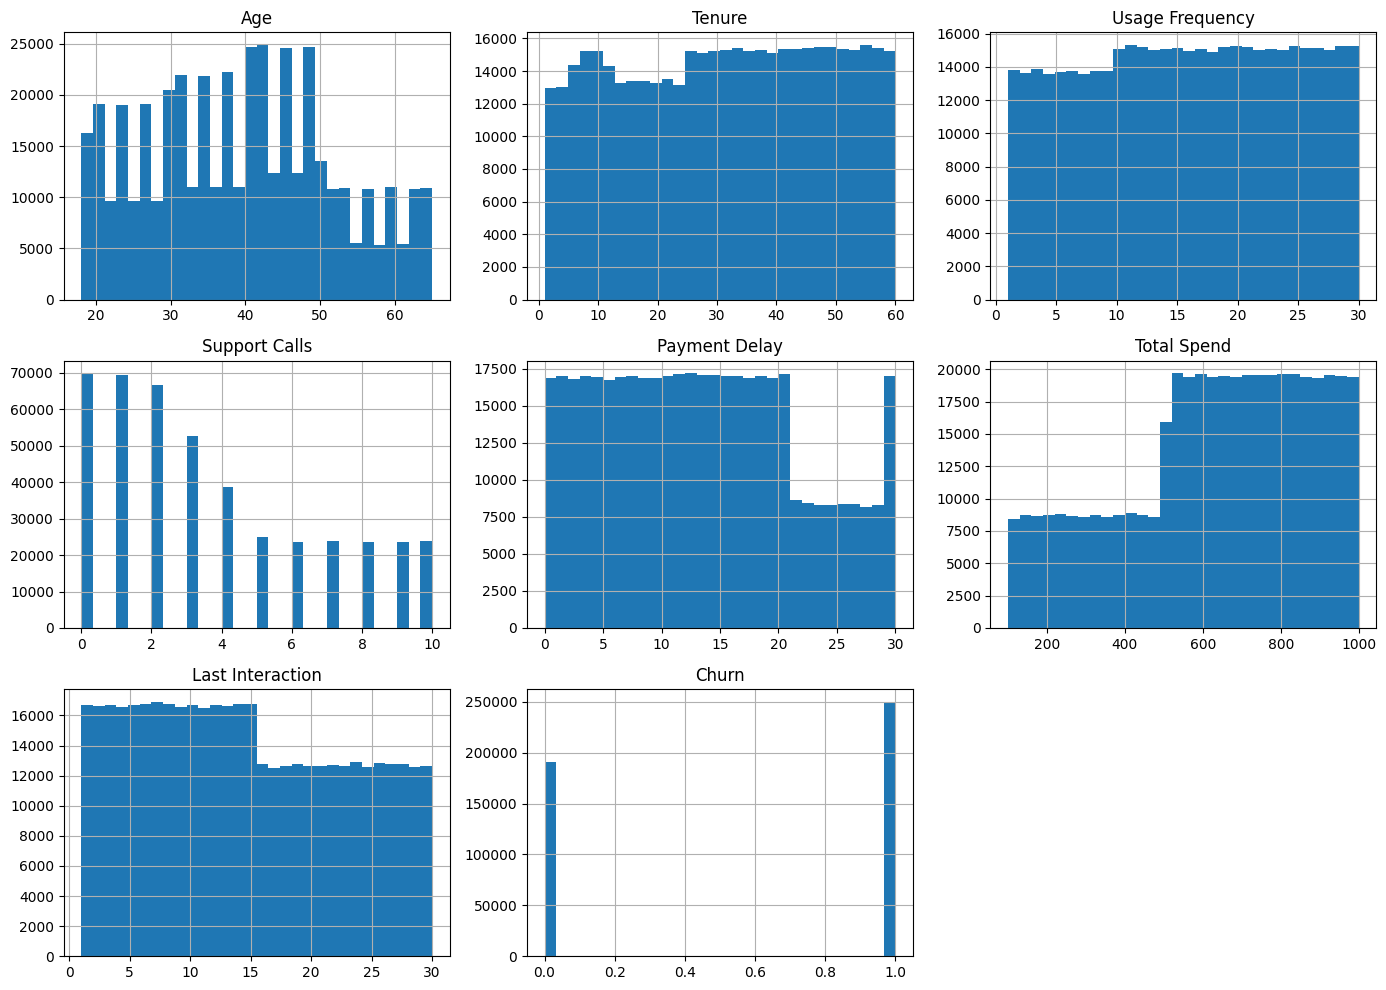

In [9]:
# Numeric distributions

df.select_dtypes(include='number').hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

### Relationship Between Features

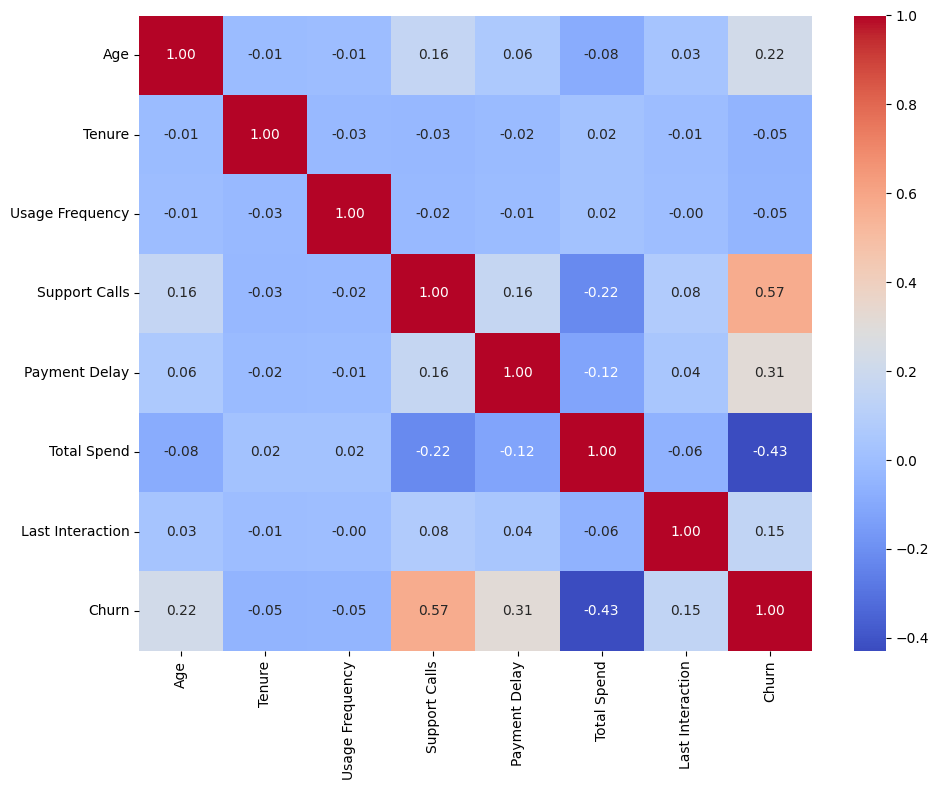

In [10]:
# Correlation heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.tight_layout()
plt.show()

In [11]:
corr = df.select_dtypes(include='number').corr()
print(corr["Churn"].sort_values(ascending=False))

Churn               1.000000
Support Calls       0.574268
Payment Delay       0.312129
Age                 0.218394
Last Interaction    0.149611
Usage Frequency    -0.046097
Tenure             -0.051919
Total Spend        -0.429362
Name: Churn, dtype: float64


### Data Preprocessing 

#### 1. Handling Missing values

In [12]:
# Count Missing Values
missing = df.isnull().sum()
missing

Age                  1
Gender               1
Tenure               1
Usage Frequency      8
Support Calls        4
Payment Delay        1
Subscription Type    7
Contract Length      5
Total Spend          9
Last Interaction     6
Churn                1
dtype: int64

In [13]:
# handle null value

from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

df.isnull().sum()

/tmp/ipykernel_14834/2604631324.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

#### 2. Outlier Handling

In [14]:
# capping outliers

def cap_outliers(df, cols, lower=0.01, upper=0.99):
    for col in cols:
        low = df[col].quantile(lower)
        high = df[col].quantile(upper)
        df[col] = df[col].clip(low, high)
    return df

num_cols = df.select_dtypes(include='number').columns.drop('Churn').tolist()
df = cap_outliers(df, num_cols)

#### 3. Scaling numerical features

In [15]:
from sklearn.preprocessing import StandardScaler

num_cols = df.select_dtypes(include='number').columns.tolist()
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#### 4. One-hot encoding

In [16]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = df.select_dtypes(include='object').drop(columns=['Churn']).columns.tolist()
le = OrdinalEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

/tmp/ipykernel_14834/3250662812.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


### Feature engineering - Deriving New feature

In [17]:
df['avg_monthly_spend'] = df['Total Spend'] / df['Tenure'].replace(0, 1)
df['support_freq_ratio'] = df['Support Calls'] / df['Tenure'].replace(0, 1)
df['usage_per_month'] = df['Usage Frequency'] / df['Tenure'].replace(0, 1)
df['has_payment_delay'] = (df['Payment Delay'] > 0).astype(int)

In [18]:
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,avg_monthly_spend,support_freq_ratio,usage_per_month,has_payment_delay
0,-0.753327,0,0.448760,-0.210518,0.454558,0.609621,2,0,1.248435,0.293064,0.873689,2.781965,1.012921,-0.469110,1
1,2.059648,0,1.028279,-1.724582,2.083120,-0.601319,0,1,-0.310353,-0.986585,0.873689,-0.301818,2.025831,-1.677154,0
2,1.255941,0,-1.000038,-1.375183,0.780271,0.609621,0,2,-1.856670,-1.335581,0.873689,1.856600,-0.780241,1.375131,1
3,1.497053,1,0.390808,0.604748,1.105983,-0.722413,2,1,-0.979592,1.689045,0.873689,-2.506581,2.829990,1.547429,0
4,-1.315922,1,0.043097,0.488281,0.454558,-0.601319,0,1,-0.060947,0.642059,0.873689,-1.414187,10.547416,11.329908,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,0.211122,1,1.318039,-0.094051,-0.848291,-1.206789,1,0,0.352153,-0.753922,-1.144572,0.267179,-0.643601,-0.071357,0
440829,-1.155181,0,-1.347749,-0.326984,-0.848291,0.851810,1,0,0.472699,-1.451912,-1.144572,-0.350732,0.629413,0.242615,1
440830,-1.074810,1,0.216952,1.303547,-0.848291,-0.964601,2,2,1.436778,-0.637590,-1.144572,6.622549,-3.910031,6.008447,0
440831,-0.914069,1,1.375990,-0.210518,-0.522578,-1.570072,2,2,-0.121012,-1.451912,-1.144572,-0.087945,-0.379783,-0.152994,0
